BigMart Sales — Data Cleaning & Visualization
Internship Project | Data Science
Dataset: BigMart Sales (8523 records, 12 features)
Tools: Python, Pandas, Matplotlib, Seaborn

Objective
Analyze the BigMart Sales dataset to uncover insights about product sales patterns across different outlet types,
locations, and product categories.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [4]:
import os
os.getcwd()

'C:\\Users\\Janani'

In [5]:
df = pd.read_csv("C:/Users/Janani/Downloads/bigmart.csv")

In [6]:
df.head()

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType,OutletSales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [7]:
df.shape

(8523, 12)

In [8]:
df.drop_duplicates()

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType,OutletSales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [9]:
df.columns

Index(['ProductID', 'Weight', 'FatContent', 'ProductVisibility', 'ProductType',
       'MRP', 'OutletID', 'EstablishmentYear', 'OutletSize', 'LocationType',
       'OutletType', 'OutletSales'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ProductID          8523 non-null   object 
 1   Weight             7060 non-null   float64
 2   FatContent         8523 non-null   object 
 3   ProductVisibility  8523 non-null   float64
 4   ProductType        8523 non-null   object 
 5   MRP                8523 non-null   float64
 6   OutletID           8523 non-null   object 
 7   EstablishmentYear  8523 non-null   int64  
 8   OutletSize         6113 non-null   object 
 9   LocationType       8523 non-null   object 
 10  OutletType         8523 non-null   object 
 11  OutletSales        8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [12]:
df.describe

<bound method NDFrame.describe of      ProductID  Weight FatContent  ProductVisibility            ProductType  \
0        FDA15   9.300    Low Fat           0.016047                  Dairy   
1        DRC01   5.920    Regular           0.019278            Soft Drinks   
2        FDN15  17.500    Low Fat           0.016760                   Meat   
3        FDX07  19.200    Regular           0.000000  Fruits and Vegetables   
4        NCD19   8.930    Low Fat           0.000000              Household   
...        ...     ...        ...                ...                    ...   
8518     FDF22   6.865    Low Fat           0.056783            Snack Foods   
8519     FDS36   8.380    Regular           0.046982           Baking Goods   
8520     NCJ29  10.600    Low Fat           0.035186     Health and Hygiene   
8521     FDN46   7.210    Regular           0.145221            Snack Foods   
8522     DRG01  14.800    Low Fat           0.044878            Soft Drinks   

           MRP Ou

In [14]:
df.isnull().sum()

ProductID               0
Weight               1463
FatContent              0
ProductVisibility       0
ProductType             0
MRP                     0
OutletID                0
EstablishmentYear       0
OutletSize           2410
LocationType            0
OutletType              0
OutletSales             0
dtype: int64

In [15]:
df["FatContent"].unique()

array(['Low Fat', 'Regular', 'low fat', 'LF', 'reg'], dtype=object)

In [16]:
df["FatContent"] = df["FatContent"].replace({"low fat" : "Low Fat", "LF" : "Low Fat", "reg" : "Regular"})

In [19]:
df["FatContent"].unique()

array(['Low Fat', 'Regular'], dtype=object)

In [20]:
df['Weight'] = df.groupby('ProductType')['Weight'].transform(
    lambda x: x.fillna(x.median())
)

In [21]:
df['OutletSize'] = df.groupby('OutletType')['OutletSize'].transform(
    lambda x: x.fillna(x.mode()[0])
)

In [24]:
df['OutletAge'] = 2025 - df['EstablishmentYear']

In [25]:
df.isnull().sum()

ProductID            0
Weight               0
FatContent           0
ProductVisibility    0
ProductType          0
MRP                  0
OutletID             0
EstablishmentYear    0
OutletSize           0
LocationType         0
OutletType           0
OutletSales          0
OutletAge            0
dtype: int64

In [26]:
df.shape

(8523, 13)

#Visualization

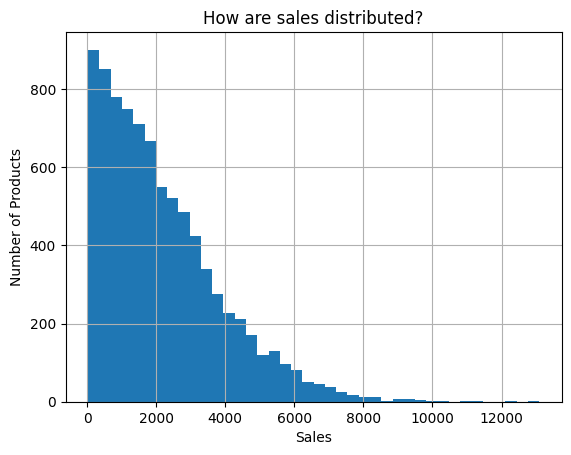

In [41]:
#Chart 1 — Distribution (Histogram)
import matplotlib.pyplot as plt

df['OutletSales'].hist(bins=40)
plt.title('How are sales distributed?')
plt.xlabel('Sales')
plt.ylabel('Number of Products')
plt.show()

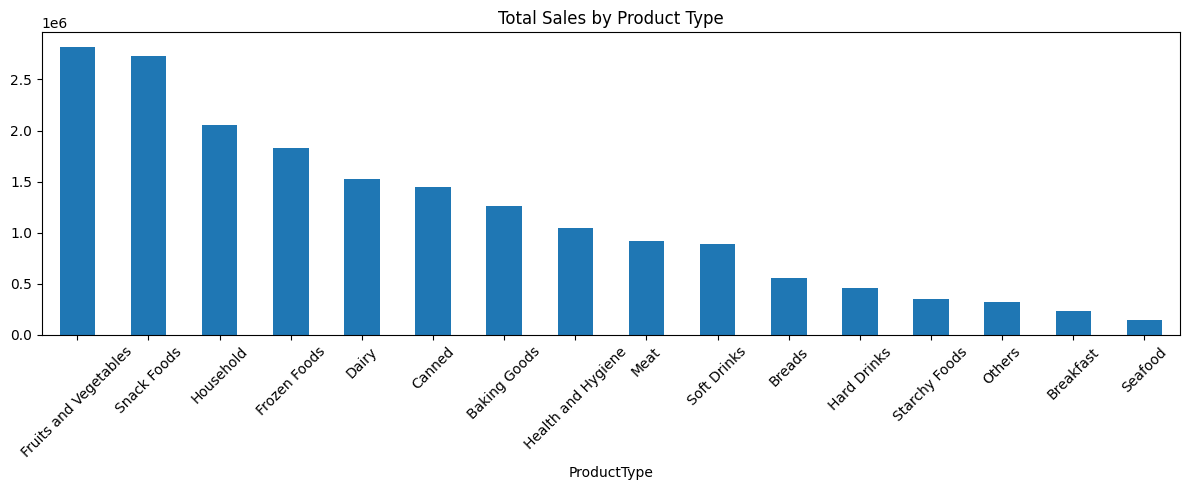

In [57]:
#Chart 2 — Bar Chart (Which product type sells most?)
import seaborn as sns

top = df.groupby('ProductType')['OutletSales'].sum().sort_values(ascending=False)
top.plot(kind='bar', figsize=(12,5))

plt.title('Total Sales by Product Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

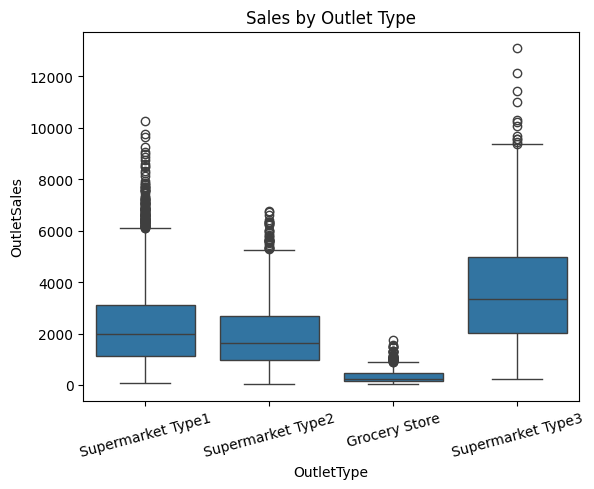

In [58]:
#Chart 3 — Box Plot (Comparing groups)
sns.boxplot(data=df, x='OutletType', y='OutletSales')
plt.title('Sales by Outlet Type')
plt.xticks(rotation=15)
plt.show()

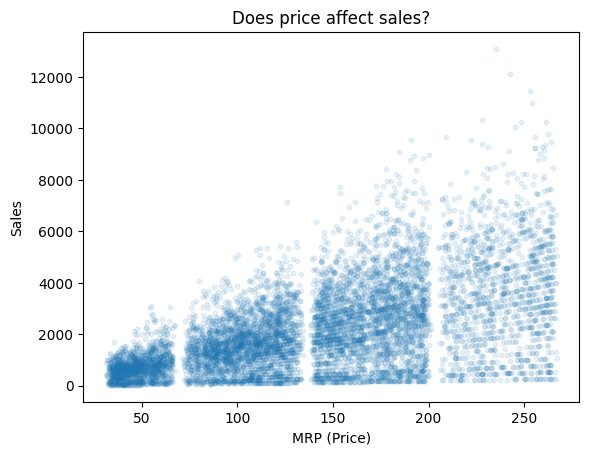

In [64]:
#Chart 4 — Scatter Plot (Relationship between two numbers)
plt.scatter(df['MRP'], df['OutletSales'], alpha=0.1, s = 10)
plt.xlabel('MRP (Price)')
plt.ylabel('Sales')
plt.title('Does price affect sales?')
plt.show()

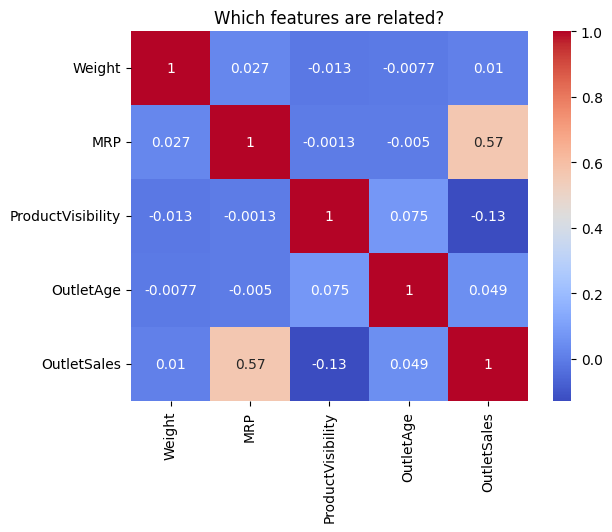

In [33]:
#Chart 5 — Heatmap (Correlation)
corr = df[['Weight','MRP','ProductVisibility','OutletAge','OutletSales']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Which features are related?')
plt.show()#